# 回帰不連続デザイン(RDD)— Colab ハンズオン

経営情報各論BⅠ/EⅠ第14回 / 因果推論 第3回 講義補助ノートブック

このノートブックは講義のサンプルコードを上から順に実行できる形にまとめたものです。
「閾値ルールの境界」を自然実験として使い、観察データから因果効果を取り出す手法を、
シミュレーションデータで手を動かしながら学びます。最後に **練習問題4問** があります。

> **使い方:** 「ランタイム → すべてのセルを実行」、または各セルで Shift+Enter。追加インストールは不要です。

---

### 目次
1. データを作る ― 閾値70点で奨学金
2. 可視化 ― ビン平均で段差を見る
3. 中心化と帯域
4. 局所線形回帰で段差(効果)を推定
5. 帯域を変えてみる
6. 偽の閾値テスト(プラセボ)
7. ファジー RDD

**練習問題(Q1〜Q4)**


## 0. 準備

In [ ]:
# matplotlibの日本語対応ライブラリをインストール
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 27.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=9782401fcfff4dfbd4d5410bfedb98661e5c9f185305ce25e536a3fc3c807623
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import japanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False
print("準備OK")

準備OK


## 1. データを作る ― 閾値70点で奨学金

題材は「入学時テストが **70点以上** なら給付型奨学金 → 4年で卒業しやすくなるか?」です。

- **running変数:** 入学時テスト点(score)
- **処置 D:** 奨学金を受給したか(70点以上なら確実に受給 = シャープRDD)
- **結果 Y:** 4年以内に卒業したか(grad)

卒業率はテスト点に滑らかに依存しつつ、**閾値70だけで +0.15 ジャンプ** するよう仕込みます。


In [ ]:
rng = np.random.default_rng(0)
n, c, true_effect = 6000, 70, 0.15

score = np.clip(rng.normal(65, 12, n), 30, 100)      # 入学時テスト点
D = (score >= c).astype(int)                         # シャープ: 閾値で確実に処置
base = 0.30 + 0.005*(score - c)                      # 卒業率の連続トレンド
prob = np.clip(base + true_effect*D, 0, 1)
grad = (rng.uniform(0,1,n) < prob).astype(int)       # 卒業した=1

df = pd.DataFrame(dict(score=score, D=D, grad=grad))
df["centered"] = df.score - c                        # 中心化(閾値を0に)
print(df.head())
print(f"\n受給(D=1): {df.D.sum()}人 / 全{n}人  (真の効果 = 卒業率+{true_effect})")

       score  D  grad   centered
0  66.508763  0     0  -3.491237
1  63.414742  0     0  -6.585258
2  72.685072  1     0   2.685072
3  66.258801  0     1  -3.741199
4  58.571968  0     0 -11.428032

受給(D=1): 2015人 / 全6000人  (真の効果 = 卒業率+0.15)


## 2. 可視化 ― ビン平均で段差を見る
推定の前に必ず図を描きます。スコアを2点刻みのビンに分け、各ビンの平均卒業率を点で示します。
閾値70の前後で点の高さがガクッと上がるのが見えるはずです。**段差が目で見えること自体がRDDの説得力** です。


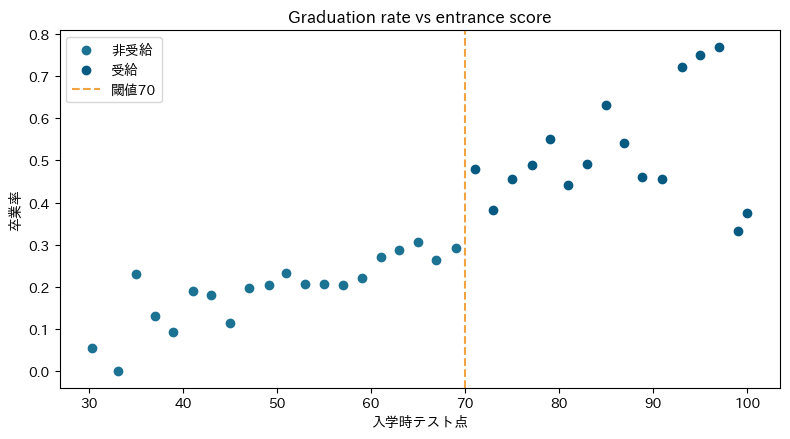

In [ ]:
def plot_rdd(df, cutoff=70, title="Graduation rate vs entrance score"):
    d = df.copy()
    d["bin"] = (d.score // 2) * 2 + 1
    g = d.groupby("bin").agg(grad=("grad","mean"), score=("score","mean")).reset_index()
    left, right = g.score < cutoff, g.score >= cutoff
    plt.figure(figsize=(8,4.5))
    plt.scatter(g.score[left],  g.grad[left],  color="#1C7293", label="非受給")
    plt.scatter(g.score[right], g.grad[right], color="#065A82", label="受給")
    plt.axvline(cutoff, color="#F2A341", ls="--", label=f"閾値{cutoff}")
    plt.xlabel("入学時テスト点"); plt.ylabel("卒業率"); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()

plot_rdd(df, c)

## 3. 中心化と帯域
- **中心化:** running変数から閾値を引き(`centered = score − 70`)、閾値を0にそろえます。
  こうすると回帰の切片や処置ダミーの係数が「閾値での値」を直接表します。
- **帯域 (bandwidth) h:** 閾値の周辺だけを使います。近いほど比較は妥当ですが、本数は減ります。


In [ ]:
h = 10
band = df[df.centered.abs() <= h].copy()
print(f"帯域 h={h}: 閾値±{h}点の {len(band)}人を使用(全{len(df)}人中)")

帯域 h=10: 閾値±10点の 3289人を使用(全6000人中)


## 4. 局所線形回帰で段差(効果)を推定
帯域内で、**左右で傾きが違える** 局所線形回帰を当てます。

`grad ~ D + centered + D:centered`

- `centered` … 左側(非受給)の傾き
- `D:centered` … 右側で傾きがどれだけ変わるか
- **`D` の係数 τ** … 閾値での卒業率の段差 = **因果効果**


In [ ]:
m = smf.ols("grad ~ D + centered + D:centered", band).fit()
tau = m.params["D"]
ci = m.conf_int().loc["D"]
print(f"RDD推定(効果) : {tau:.3f}")
print(f"95%CI         : [{ci[0]:.3f}, {ci[1]:.3f}]")
print(f"真値          : +{true_effect}  → CIが真値を含むことを確認")

RDD推定(効果) : 0.127
95%CI         : [0.063, 0.190]
真値          : +0.15  → CIが真値を含むことを確認


### 推定した回帰直線を重ねて描く
左右それぞれの回帰直線と、閾値での段差を可視化します。


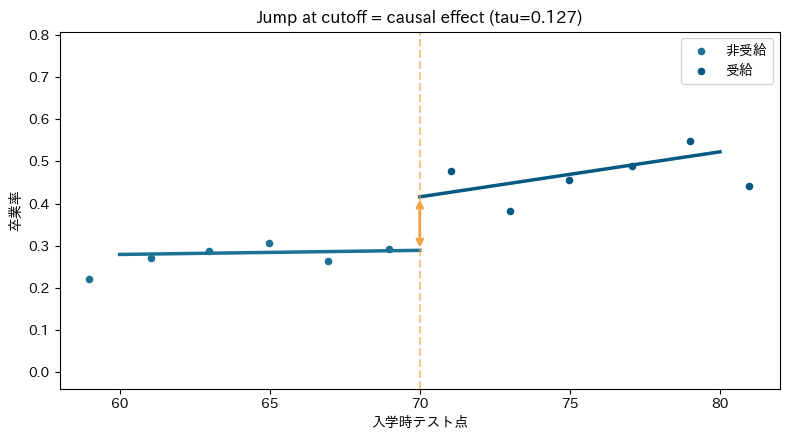

In [ ]:
d = df.copy(); d["bin"] = (d.score // 2)*2 + 1
g = d.groupby("bin").agg(grad=("grad","mean"), score=("score","mean")).reset_index()
gl, gr = g.score < c, g.score >= c

xs_l = np.linspace(c-h, c, 50); xs_r = np.linspace(c, c+h, 50)
pred = lambda xs, D: (m.params["Intercept"] + m.params["D"]*D
                      + m.params["centered"]*(xs-c) + m.params["D:centered"]*D*(xs-c))

plt.figure(figsize=(8,4.5))
plt.scatter(g.score[gl], g.grad[gl], color="#1C7293", s=20, label="非受給")
plt.scatter(g.score[gr], g.grad[gr], color="#065A82", s=20, label="受給")
plt.plot(xs_l, pred(xs_l, 0), color="#1C7293", lw=2.5)
plt.plot(xs_r, pred(xs_r, 1), color="#065A82", lw=2.5)
# 閾値での段差を矢印で
plt.annotate("", xy=(c, pred(np.array([c]),1)[0]), xytext=(c, pred(np.array([c]),0)[0]),
             arrowprops=dict(arrowstyle="<->", color="#F2A341", lw=2))
plt.axvline(c, color="#F2A341", ls="--", alpha=0.6)
plt.xlim(c-h-2, c+h+2)
plt.xlabel("入学時テスト点"); plt.ylabel("卒業率")
plt.title(f"Jump at cutoff = causal effect (tau={tau:.3f})")
plt.legend(); plt.tight_layout(); plt.show()

## 5. 帯域を変えてみる
帯域はRDDの最重要のチューニングです。**狭い=低バイアス高分散、広い=低分散だがバイアスの恐れ**。


In [ ]:
def rdd_estimate(df, h=10, degree=1):
    band = df[df.centered.abs() <= h].copy()
    terms = ["D"]
    for k in range(1, degree+1):
        band[f"c{k}"] = band.centered**k
        terms += [f"c{k}", f"D:c{k}"]
    mm = smf.ols("grad ~ " + " + ".join(terms), band).fit()
    ci = mm.conf_int().loc["D"]
    return mm.params["D"], ci[0], ci[1], len(band)

print("真の効果 = +0.15\n")
for hh in [3, 5, 10, 20, 40]:
    t, lo, hi, nused = rdd_estimate(df, h=hh)
    print(f"  h={hh:2d}: τ={t:.3f}, 95%CI=[{lo:.3f},{hi:.3f}], CI幅={hi-lo:.3f}, n={nused}")

真の効果 = +0.15

  h= 3: τ=0.177, 95%CI=[0.063,0.291], CI幅=0.227, n=1063
  h= 5: τ=0.181, 95%CI=[0.092,0.269], CI幅=0.176, n=1728
  h=10: τ=0.127, 95%CI=[0.063,0.190], CI幅=0.126, n=3289
  h=20: τ=0.124, 95%CI=[0.078,0.170], CI幅=0.093, n=5282
  h=40: τ=0.126, 95%CI=[0.085,0.166], CI幅=0.081, n=6000


帯域を広げると使用データが増え、CI幅(不確実性)が縮みます。一方で狭い帯域は閾値近傍だけの
素直な比較になります。両者のバランスを取るのがRDDの実務です。


## 6. 偽の閾値テスト(プラセボ)
RDDが本物なら、段差が出るのは **真の閾値だけ**。処置が起きていない **対照側(閾値70未満)** に
偽の閾値を置くと、段差はほぼ0(CIが0を含む)になるはずです。これは妥当性チェックの定番です。


In [ ]:
def rdd_at(df, fake_cutoff, h=8, control_side_only=False):
    d = df.copy()
    if control_side_only:
        d = d[d.score < 70]               # 処置が起きていない対照側だけ
    d["cf"] = d.score - fake_cutoff
    d["Df"] = (d.score >= fake_cutoff).astype(int)
    band = d[d.cf.abs() <= h]
    mm = smf.ols("grad ~ Df + cf + Df:cf", band).fit()
    return mm.params["Df"], mm.conf_int().loc["Df"].tolist()

tau70, ci70 = rdd_at(df, 70, h=10)
print(f"本物の閾値70 : τ={tau70:+.3f}, CI=[{ci70[0]:+.3f}, {ci70[1]:+.3f}]  ← 0から離れる\n")
print("偽の閾値(対照側のみ):")
for fk in [55, 58, 62, 65]:
    t, ci = rdd_at(df, fk, h=6, control_side_only=True)
    ok = "✓ 0を含む" if ci[0] <= 0 <= ci[1] else "← 要注意"
    print(f"  偽の閾値{fk} : τ={t:+.3f}, CI=[{ci[0]:+.3f}, {ci[1]:+.3f}]  {ok}")

本物の閾値70 : τ=+0.127, CI=[+0.063, +0.190]  ← 0から離れる

偽の閾値(対照側のみ):
  偽の閾値55 : τ=-0.054, CI=[-0.133, +0.025]  ✓ 0を含む
  偽の閾値58 : τ=-0.019, CI=[-0.092, +0.054]  ✓ 0を含む
  偽の閾値62 : τ=+0.006, CI=[-0.065, +0.077]  ✓ 0を含む
  偽の閾値65 : τ=-0.039, CI=[-0.118, +0.039]  ✓ 0を含む


## 7. ファジー RDD
これまでは閾値で受給が100%切り替わる **シャープ** でした。現実には70点以上でも辞退する人、
未満でも別枠で受ける人がいます(**ファジー**)。このとき効果は

**(Yの段差) ÷ (受給確率の段差)**

で補正します(操作変数法と同じ発想)。


In [ ]:
def make_fuzzy(true_effect=0.15, cutoff=70, n=6000, seed=1):
    r = np.random.default_rng(seed)
    score = np.clip(r.normal(65, 12, n), 30, 100)
    p_treat = np.where(score >= cutoff, 0.80, 0.20)    # 受給確率: 下20%→上80%
    treat = (r.uniform(0,1,n) < p_treat).astype(int)
    base = 0.30 + 0.005*(score - cutoff)
    prob = np.clip(base + true_effect*treat, 0, 1)
    grad = (r.uniform(0,1,n) < prob).astype(int)
    d = pd.DataFrame(dict(score=score, treat=treat, grad=grad))
    d["centered"] = d.score - cutoff
    d["above"] = (d.score >= cutoff).astype(int)
    return d

fz = make_fuzzy(cutoff=70)
band = fz[fz.centered.abs() <= 10].copy()

m_y = smf.ols("grad ~ above + centered + above:centered", band).fit()
jump_Y = m_y.params["above"]                              # 分子: Yの段差
m_t = smf.ols("treat ~ above + centered + above:centered", band).fit()
jump_T = m_t.params["above"]                              # 分母: 受給確率の段差
fuzzy_effect = jump_Y / jump_T

print(f"真の効果 = +0.15\n")
print(f"  Yの段差(単純)          : {jump_Y:.3f}   ← 効果が薄まって過小")
print(f"  受給確率の段差          : {jump_T:.3f}   (0.8-0.2=0.6 付近)")
print(f"  ファジーRDD効果 (割り戻し): {fuzzy_effect:.3f}   ← 真値+0.15に補正 ✓")

真の効果 = +0.15

  Yの段差(単純)          : 0.119   ← 効果が薄まって過小
  受給確率の段差          : 0.662   (0.8-0.2=0.6 付近)
  ファジーRDD効果 (割り戻し): 0.180   ← 真値+0.15に補正 ✓


### まとめ

- RDDは「処置がある連続変数の閾値で機械的に決まる」状況で、**閾値での結果の段差を因果効果** として読む。
- 閾値直近の人どうしは偶然で処置が分かれる(擬似ランダム)ので、**未観測交絡があっても段差は妥当**。
- **シャープ**(100%切替)はそのまま段差を読む。**ファジー**(確率的)は受給確率の段差で割って補正。
- 命となる前提は **閾値での連続性**。効果は **閾値近傍(LATE)** に限られる点にも注意。

| 手法 | 必要な状況 | 打ち消せる交絡 |
|---|---|---|
| 回帰不連続 (RDD) | 閾値ルールがある | 閾値で連続なら未観測でも可 |


---
# 練習問題

ここからは手を動かす番です。各問の `# TODO` を埋めて実行し、問いに答えてください。
模範解答は別ノートブック `rdd_solutions.ipynb` にあります。


## 0. 練習用の共通関数
パラメータを変えてデータを作り直せるよう関数化しておきます。


In [ ]:
def make_rdd_data(true_effect=0.15, cutoff=70, n=6000, seed=0):
    r = np.random.default_rng(seed)
    score = np.clip(r.normal(65, 12, n), 30, 100)
    D = (score >= cutoff).astype(int)
    base = 0.30 + 0.005*(score - cutoff)
    prob = np.clip(base + true_effect*D, 0, 1)
    grad = (r.uniform(0,1,n) < prob).astype(int)
    d = pd.DataFrame(dict(score=score, D=D, grad=grad))
    d["centered"] = d.score - cutoff
    return d

# rdd_estimate, rdd_at, make_fuzzy は上のセルで定義済み(そのまま使えます)
df_ex = make_rdd_data(cutoff=70)
print("make_rdd_data() を定義。rdd_estimate / rdd_at / make_fuzzy は本文のものを再利用します")

## Q1. 帯域 (bandwidth) の感度

> 帯域 `h` を変えると、RDD推定 τ・95%CI・使用サンプル数はどう変わる?
> いくつかの h で `rdd_estimate` を呼び出して表にまとめ、「狭い vs 広い」のトレードオフを説明してください。


In [ ]:
# Q1-TODO: 各 h について τ・CI幅・使用数を集めて DataFrame にしよう
hs = [3, 5, 10, 20, 40]
rows = []
for h in hs:
    # TODO: tau, lo, hi, nused = rdd_estimate(df_ex, h=h, degree=1)
    # TODO: rows.append({"h": h, "τ": round(tau,3), "CI幅": round(hi-lo,3), "使用数": nused})
    pass
# TODO: print(pd.DataFrame(rows))


**答えを書く欄(Q1):** 帯域を狭めると τ と CI幅はどう動いた? なぜそのトレードオフが生じる?

→

## Q2. 多項式の次数の影響

> 同じ帯域で、回帰の次数を 1次 → 2次 → 4次 と上げると推定はどう変わる?
> 高次にすると何が起きるでしょうか(ヒント:広い帯域 h=30 で観察)。


In [ ]:
# Q2-TODO: 次数を変えて τ を比較しよう(帯域は広めの h=30 で)
degrees = [1, 2, 4]
for deg in degrees:
    # TODO: tau, lo, hi, nused = rdd_estimate(df_ex, h=30, degree=deg)
    # TODO: print(f"次数{deg}: τ={tau:.3f}, CI=[{lo:.3f},{hi:.3f}]")
    pass
# 参考: 狭い帯域×1次(最も素直)も出すと比較しやすい
# t0, l0, h0, _ = rdd_estimate(df_ex, h=8, degree=1); print(f"参考(h=8,1次): τ={t0:.3f}")


**答えを書く欄(Q2):** 次数を上げると推定はどう変わった? 高次多項式の危うさは何か?

→

## Q3. 偽の閾値テスト(プラセボ)

> 処置が起きていない **対照側(閾値70未満)だけ** を使い、偽の閾値(例:58点・65点)で段差を測ると
> どうなるべき? 実際に確認し、本物の閾値70と比べてください(`rdd_at` の `control_side_only=True` を使う)。


In [ ]:
# 動作確認: 本物の閾値70(全データ)
tau70, ci70 = rdd_at(df_ex, 70, h=10)
print(f"本物の閾値70: τ={tau70:.3f}, CI={[round(x,3) for x in ci70]}")

# Q3-TODO: 対照側で偽の閾値 58, 65 を検定し、70と比べよう
for fk in [58, 65]:
    # TODO: tau_f, ci_f = rdd_at(df_ex, fk, h=6, control_side_only=True)
    # TODO: print(f"偽の閾値{fk}: τ={tau_f:.3f}, CI={[round(x,3) for x in ci_f]}")
    pass


**答えを書く欄(Q3):** 偽の閾値での段差はどうなった? これが確認できると何が言える?

→

## Q4. ファジー RDD

> 受給が確率的なファジーデータで、(a)単純なYの段差 と (b)受給確率の段差で割った補正後の効果を計算し、
> 真値+0.15と比べてください。なぜ割り算が必要かを説明しましょう。


In [ ]:
fz_q4 = make_fuzzy(cutoff=70)
band_q4 = fz_q4[fz_q4.centered.abs() <= 10].copy()
print("閾値の上下での平均受給率:")
print(fz_q4.groupby("above")["treat"].mean())

# Q4-TODO: 分子(Yの段差)と分母(受給確率の段差)を回帰で求め、割り戻して効果を出そう
# m_y = smf.ols("grad ~ above + centered + above:centered", band_q4).fit()
# m_t = smf.ols("treat ~ above + centered + above:centered", band_q4).fit()
# jump_Y = m_y.params["above"]; jump_T = m_t.params["above"]
# TODO: jump_Y(単純な段差) と jump_Y/jump_T(補正後) を真値0.15と比較して print


**答えを書く欄(Q4):** 単純なYの段差と補正後の値、どちらが真値+0.15に近い? なぜ割り算が必要か?

→

---

### 解答のヒント
- 各 `# TODO` を埋め、出力を確認したら「答えを書く欄」に2〜3文で考察を記入。
- スライドの図(閾値でのジャンプ・バイアスvs分散・ファジーRDD)と結びつけて説明できると良い。
